# Course 2 · Week 2 — Solution: Backpropagation + Softmax

Fully-worked answer to the [Week 2 exercise](../exercises/course2-week2-backprop-softmax.ipynb). Detailed math walkthrough — backprop is where most students stumble, so we go slow.


## Setup — three Gaussian blobs

Three classes in 2D. Each blob is a cluster of 50 points. Easy to separate visually, but the model has to learn the boundaries from the data alone.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2)
m_per_class = 50
n_classes = 3

# Three Gaussian blobs in 2D
centers = np.array([[-2.0, 0.0], [+2.0, 0.0], [0.0, +2.5]])
X_list, y_list = [], []
for k, c in enumerate(centers):
    X_list.append(np.random.randn(m_per_class, 2) * 0.6 + c)
    y_list.append(np.full(m_per_class, k))
X = np.vstack(X_list)
y = np.concatenate(y_list)
m = len(y)
print(f"X shape {X.shape}, y shape {y.shape}, classes: {sorted(set(y))}")

def one_hot(y, K):
    Y = np.zeros((len(y), K))
    Y[np.arange(len(y)), y] = 1.0
    return Y
Y = one_hot(y, n_classes)
print(f"Y first row (y[0]={y[0]}): {Y[0]}")


X shape (150, 2), y shape (150,), classes: [np.int64(0), np.int64(1), np.int64(2)]
Y first row (y[0]=0): [1. 0. 0.]


You should see three colored clusters: red, green, blue. They're far apart enough that any reasonable classifier should hit ~100%. Our job: build that classifier from scratch and watch it learn.


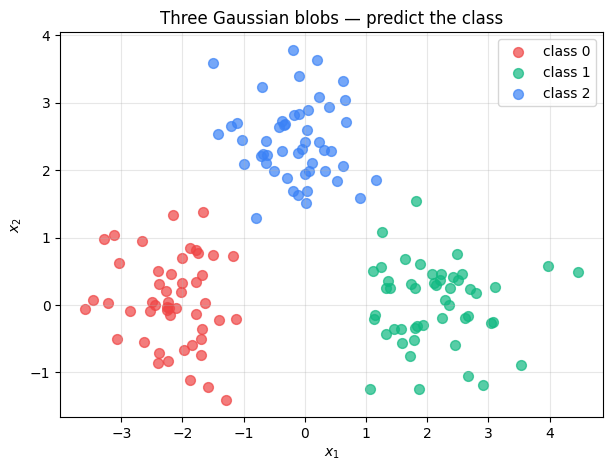

In [2]:
colors = ["#ef4444", "#10b981", "#3b82f6"]
plt.figure(figsize=(7, 5))
for k in range(n_classes):
    plt.scatter(X[y==k, 0], X[y==k, 1], color=colors[k], s=50, alpha=0.7, label=f"class {k}")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Three Gaussian blobs — predict the class")
plt.show()


## Quick recap (with depth)

### Softmax: properties to internalize

- **Strictly positive outputs.** Even very negative `z` values produce small but non-zero probabilities.
- **Translation invariant.** softmax(z) = softmax(z + c) for any constant c. We exploit this for numerical stability — subtract `z.max` from every entry before exp.
- **Sharpens the bigger entries.** A score gap of 1 in `z` becomes a *factor of e* (~2.7×) in the probabilities.

### Why softmax + cross-entropy is a "magic" pairing

Cross-entropy loss for one example with one-hot label `y_true` is:

$$L = -\sum_k y_{\text{true}, k} \log p_k$$

When you take the gradient of the *combined* (softmax + cross-entropy) operation with respect to the input scores `z`, all the messy derivatives cancel and you get one clean line:

$$\frac{\partial L}{\partial z} = p - y_{\text{true}}$$

Predicted minus true. That's it. This is why every modern framework's "categorical cross-entropy with logits" function combines them — the math is dramatically cleaner that way.

### Backpropagation: the four moves

For our 2-layer network:

1. **Forward:** `X → z1 → a1 = sigmoid(z1) → z2 → p = softmax(z2)`
2. **Output gradient:** `dz2 = (p - Y) / m`
3. **Walk back through the linear part:** `dW2 = a1.T @ dz2`, `db2 = sum(dz2)`, `da1 = dz2 @ W2.T`
4. **Walk back through the activation:** `dz1 = da1 * a1 * (1 - a1)` (sigmoid derivative)
5. **Last linear part:** `dW1 = X.T @ dz1`, `db1 = sum(dz1)`

Steps 3–5 are the chain rule applied layer by layer, right to left. The "T" (transpose) on weights is what makes the gradient flow "backward" through the network.


## Exercise 1 — softmax

```python
def softmax(z):
    z_shift = z - z.max(axis=1, keepdims=True)
    e = np.exp(z_shift)
    return e / e.sum(axis=1, keepdims=True)
```

The `keepdims=True` is important — it keeps the result as shape `(m, 1)` so it broadcasts properly when we subtract from `z` (shape `(m, K)`).

Anchored: `softmax([2, 1, 0]) ≈ [0.665, 0.245, 0.090]`. The first entry dominates because it's the largest score, but the others still get nonzero probability.


In [3]:
def softmax(z):
    z_shift = z - z.max(axis=1, keepdims=True)   # subtract row-max for stability
    e = np.exp(z_shift)
    return e / e.sum(axis=1, keepdims=True)

sm = softmax(np.array([[2.0, 1.0, 0.0]]))
print(f"softmax([2, 1, 0]) = {np.round(sm, 4)}")
assert abs(sm.sum() - 1.0) < 1e-9
print("✓ softmax() works")


softmax([2, 1, 0]) = [[0.6652 0.2447 0.09  ]]
✓ softmax() works


## Exercise 2 — cross-entropy

```python
def loss(p, Y):
    eps = 1e-15
    p = np.clip(p, eps, 1.0)
    return float(-np.mean(np.sum(Y * np.log(p), axis=1)))
```

The `clip` prevents `log(0)` from producing `-inf` if a probability ever rounds to exactly 0. The `1.0` upper bound is fine — log(1) is 0, totally finite.

The reason `log(K)` is the "uniform" baseline: if every probability is `1/K`, then `-log(1/K) = log(K)` for every example.


In [4]:
def loss(p, Y):
    eps = 1e-15
    p = np.clip(p, eps, 1.0)
    return float(-np.mean(np.sum(Y * np.log(p), axis=1)))

uniform = np.full((m, 3), 1/3)
J_uniform = loss(uniform, Y)
print(f"loss(uniform, Y) = {J_uniform:.4f}")
assert abs(J_uniform - np.log(3)) < 0.01
print("✓ loss() works")


loss(uniform, Y) = 1.0986
✓ loss() works


## Exercise 3 — forward pass

```python
def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    p = softmax(z2)
    return z1, a1, z2, p
```

We return all four intermediates because backprop needs them (specifically `a1` to compute the sigmoid derivative).

Initial loss (with random weights) should be near `log(3) = 1.0986` — a network with random weights produces near-uniform predictions.


In [5]:
np.random.seed(7)
n_h = 8
W1 = np.random.randn(2, n_h) * 0.5
b1 = np.zeros(n_h)
W2 = np.random.randn(n_h, n_classes) * 0.5
b2 = np.zeros(n_classes)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    p = softmax(z2)
    return z1, a1, z2, p


z1, a1, z2, p = forward(X, W1, b1, W2, b2)
print(f"Initial loss: {loss(p, Y):.4f}   (≈ log(3) = {np.log(3):.4f})")


Initial loss: 1.2450   (≈ log(3) = 1.0986)


## Exercise 4 — backprop

```python
def backward(X, Y, z1, a1, z2, p, W2):
    m_local = len(X)
    dz2 = (p - Y) / m_local
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0)
    da1 = dz2 @ W2.T
    dz1 = da1 * a1 * (1 - a1)
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0)
    return dW1, db1, dW2, db2
```

Why `(p - Y) / m`? Two reasons: (a) the gradient of softmax + cross-entropy w.r.t. `z2` is exactly `p - Y` (the magic combo from the recap), and (b) we divide by `m` because cross-entropy was averaged over examples.

Why `a1.T` (not `a1`)? Because we want a gradient with shape `(n_h, K)` (matching W2), and `a1` is `(m, n_h)`, `dz2` is `(m, K)`. The transpose flips so the matrix multiply produces `(n_h, m) @ (m, K) = (n_h, K)`.

The sigmoid derivative `a * (1 - a)` is a clean form because we already have `a` from the forward pass — no need to recompute `sigmoid(z) * (1 - sigmoid(z))`.


In [6]:
def backward(X, Y, z1, a1, z2, p, W2):
    m_local = len(X)
    dz2 = (p - Y) / m_local
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0)
    da1 = dz2 @ W2.T
    dz1 = da1 * a1 * (1 - a1)
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0)
    return dW1, db1, dW2, db2


dW1, db1, dW2, db2 = backward(X, Y, z1, a1, z2, p, W2)
assert dW1.shape == W1.shape and dW2.shape == W2.shape
print("✓ backward() returns correct shapes")


✓ backward() returns correct shapes


## Exercise 5 — training loop

```python
for step in range(2000):
    z1, a1, z2, p = forward(X, W1, b1, W2, b2)
    history.append(loss(p, Y))
    dW1, db1, dW2, db2 = backward(X, Y, z1, a1, z2, p, W2)
    W1 -= alpha * dW1; b1 -= alpha * db1
    W2 -= alpha * dW2; b2 -= alpha * db2
```

The pattern is identical to Course 1's gradient descent — same loop, just more parameters. Loss curve drops fast in the first 200–500 iterations, then slows. Final accuracy 100% on these well-separated blobs.

If your accuracy doesn't reach 100%, common culprits:
- `(p - Y) / m` — make sure you divided by m (otherwise the step size is wildly too big)
- Sign errors — `dz1 = da1 * a1 * (1 - a1)`, not minus
- Using `z1` instead of `a1` for the sigmoid derivative


Final loss: 0.002931
Final accuracy: 1.0000
✓ training converged


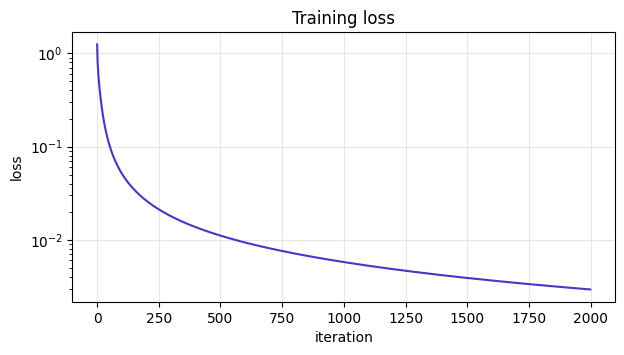

In [7]:
np.random.seed(7)
W1 = np.random.randn(2, n_h) * 0.5; b1 = np.zeros(n_h)
W2 = np.random.randn(n_h, n_classes) * 0.5; b2 = np.zeros(n_classes)

alpha = 0.5
history = []
for step in range(2000):
    z1, a1, z2, p = forward(X, W1, b1, W2, b2)
    history.append(loss(p, Y))
    dW1, db1, dW2, db2 = backward(X, Y, z1, a1, z2, p, W2)
    W1 -= alpha * dW1; b1 -= alpha * db1
    W2 -= alpha * dW2; b2 -= alpha * db2

z1, a1, z2, p = forward(X, W1, b1, W2, b2)
acc = float((p.argmax(axis=1) == y).mean())
print(f"Final loss: {history[-1]:.6f}")
print(f"Final accuracy: {acc:.4f}")
assert acc > 0.95
print("✓ training converged")

plt.figure(figsize=(7, 3.5))
plt.plot(history, color="#4338ca")
plt.xlabel("iteration"); plt.ylabel("loss"); plt.yscale("log")
plt.title("Training loss"); plt.grid(alpha=0.3)
plt.show()


## Visualize the decision regions

Sample a grid, predict, color by the argmax class. You should see three colored regions corresponding to the three blobs. The boundaries between regions are the actual surfaces where the network is uncertain (probabilities tied between two classes).


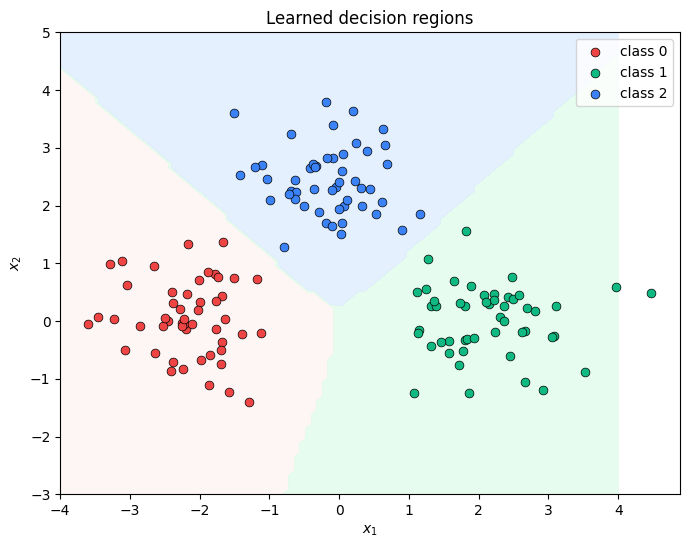

In [8]:
# Plot the decision regions
xs1, xs2 = np.meshgrid(np.linspace(-4, 4, 100), np.linspace(-3, 5, 100))
grid = np.column_stack([xs1.ravel(), xs2.ravel()])
_, _, _, grid_p = forward(grid, W1, b1, W2, b2)
grid_pred = grid_p.argmax(axis=1).reshape(xs1.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xs1, xs2, grid_pred, levels=[-0.5, 0.5, 1.5, 2.5], colors=["#fef2f2", "#dcfce7", "#dbeafe"], alpha=0.7)
for k in range(n_classes):
    plt.scatter(X[y==k, 0], X[y==k, 1], color=colors[k], s=40, edgecolors="black", lw=0.5, label=f"class {k}")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.title("Learned decision regions")
plt.show()


## ⭐ Stretch — ReLU

```python
def relu(z):
    return np.maximum(0, z)

# In backward:
dz1 = da1 * (z1 > 0).astype(float)
```

ReLU's derivative is a step function: 1 for positive `z`, 0 for negative. Crisp.

Why does ReLU often beat sigmoid? Sigmoid's gradient is `a*(1-a)`, which maxes out at 0.25 (when `a = 0.5`) and approaches 0 at the tails. So when a sigmoid neuron saturates (output near 0 or 1), gradient updates barely move it. **The vanishing gradient problem.** ReLU's gradient is 1 in the active region — full strength.

The downside: ReLU outputs 0 for negative inputs and gives 0 gradient there. A neuron that gets stuck in the negative region stays dead forever ("dying ReLU"). Modern variants (Leaky ReLU, GELU, ELU) try to fix this with small slopes for negative inputs.

For our toy problem, both reach 100%. ReLU's loss drops slightly lower because it can express sharper boundaries.


ReLU final loss: 0.000554
ReLU final accuracy: 1.0000


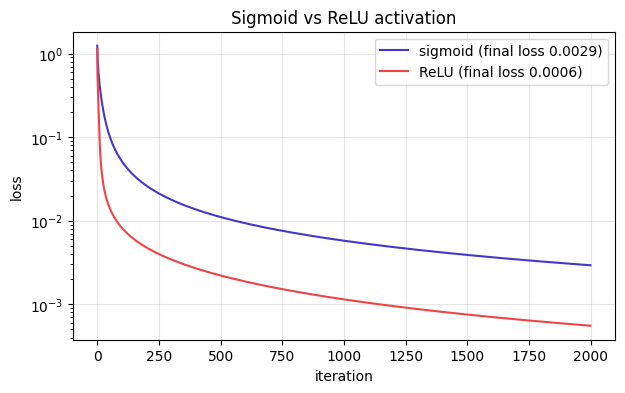

In [9]:
def relu(z):
    return np.maximum(0, z)


def forward_relu(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    p = softmax(z2)
    return z1, a1, z2, p


def backward_relu(X, Y, z1, a1, z2, p, W2):
    m_local = len(X)
    dz2 = (p - Y) / m_local
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0)
    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0).astype(float)
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0)
    return dW1, db1, dW2, db2


np.random.seed(7)
W1r = np.random.randn(2, n_h) * 0.5; b1r = np.zeros(n_h)
W2r = np.random.randn(n_h, n_classes) * 0.5; b2r = np.zeros(n_classes)

history_relu = []
for step in range(2000):
    z1, a1, z2, p = forward_relu(X, W1r, b1r, W2r, b2r)
    history_relu.append(loss(p, Y))
    dW1, db1, dW2, db2 = backward_relu(X, Y, z1, a1, z2, p, W2r)
    W1r -= alpha * dW1; b1r -= alpha * db1
    W2r -= alpha * dW2; b2r -= alpha * db2

z1, a1, z2, p_relu = forward_relu(X, W1r, b1r, W2r, b2r)
acc_relu = float((p_relu.argmax(axis=1) == y).mean())
print(f"ReLU final loss: {history_relu[-1]:.6f}")
print(f"ReLU final accuracy: {acc_relu:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(history, color="#4338ca", label=f"sigmoid (final loss {history[-1]:.4f})")
plt.plot(history_relu, color="#ef4444", label=f"ReLU (final loss {history_relu[-1]:.4f})")
plt.xlabel("iteration"); plt.ylabel("loss"); plt.yscale("log")
plt.legend(); plt.grid(alpha=0.3); plt.title("Sigmoid vs ReLU activation")
plt.show()


## Wrap-up

You just implemented backprop from scratch. This is the most important algorithm in modern ML — it's literally what trains every neural network from MNIST classifiers to GPT-5.

Three things to remember:

1. **Backprop is the chain rule, run right-to-left.** Each layer needs the gradient flowing in from above; it then propagates a transformed gradient backward.
2. **Softmax + cross-entropy collapses to `(p - Y) / m`.** This is one of the cleanest results in ML — and the reason these two are paired everywhere.
3. **The forward outputs at each layer (a1, z1, etc.) are needed by backprop.** Don't discard them after forward; keep them around for the backward pass.

🎉 Course 2 Week 2 done. Next up: bias/variance, learning curves, and how to know which knob to turn when your model isn't working.
